In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
try:
    df = pd.read_csv('../build/scaling_data.csv')
    # Clean the data: remove the 8 and 16 core runs that failed
    df = df[df['ComputeTime_sec'] != 'ERROR'].copy()
    df['ComputeTime_sec'] = pd.to_numeric(df['ComputeTime_sec'])
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: scaling_data.csv not found.")

Data loaded successfully!


In [ ]:
cores = df['Cores'].values
compute_times = df['ComputeTime_sec'].values


array([1, 2, 4])

In [10]:
ideal_speedup = cores
actual_speedup = compute_times[0] / compute_times
efficiency = (actual_speedup / cores) * 100

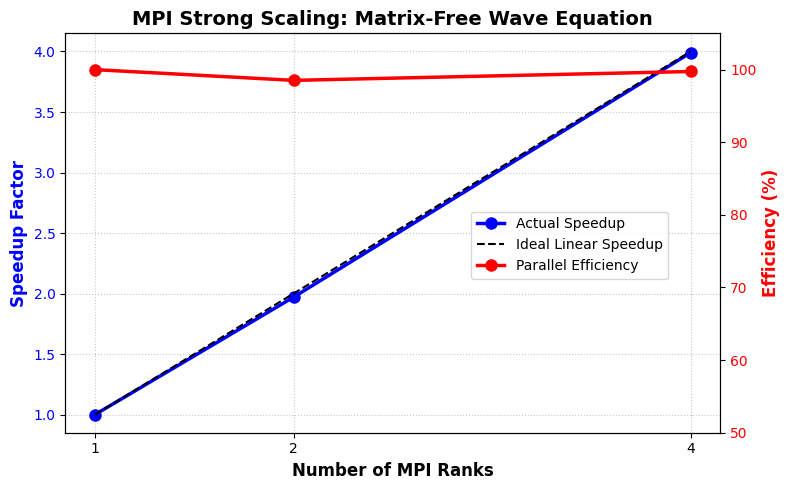

,Cores,ComputeTime_sec
0,1,1077.40
1,2,546.78
2,4,270.04


In [11]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(cores, actual_speedup, 'bo-', linewidth=2.5, markersize=8, label='Actual Speedup')
ax1.plot(cores, ideal_speedup, 'k--', linewidth=1.5, label='Ideal Linear Speedup')
ax1.set_xlabel('Number of MPI Ranks', fontsize=12, fontweight='bold')
ax1.set_ylabel('Speedup Factor', color='b', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticks(cores)
ax1.grid(True, linestyle=':', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(cores, efficiency, 'ro-', linewidth=2.5, markersize=8, label='Parallel Efficiency')
ax2.set_ylabel('Efficiency (%)', color='r', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(50, 105)

plt.title('MPI Strong Scaling: Matrix-Free Wave Equation', fontsize=14, fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.85, 0.5))

plt.tight_layout()
plt.savefig('hpc_scaling_graph.png', dpi=300)
plt.show()

# Display the raw data table
display(df)